# Project — Chapter 86: Curve Fitting

> **Prerequisites:** ch072 (Fitting), ch073 (Error and Residuals)
>
> **Concepts:** Least squares, linearization, nonlinear grid search, R², residual analysis
>
> **Output:** Fit multiple model families to real-shaped datasets and compare
>
> **Difficulty:** Intermediate | ~45 minutes

---

## Stage 1 — Multi-Family Fitting

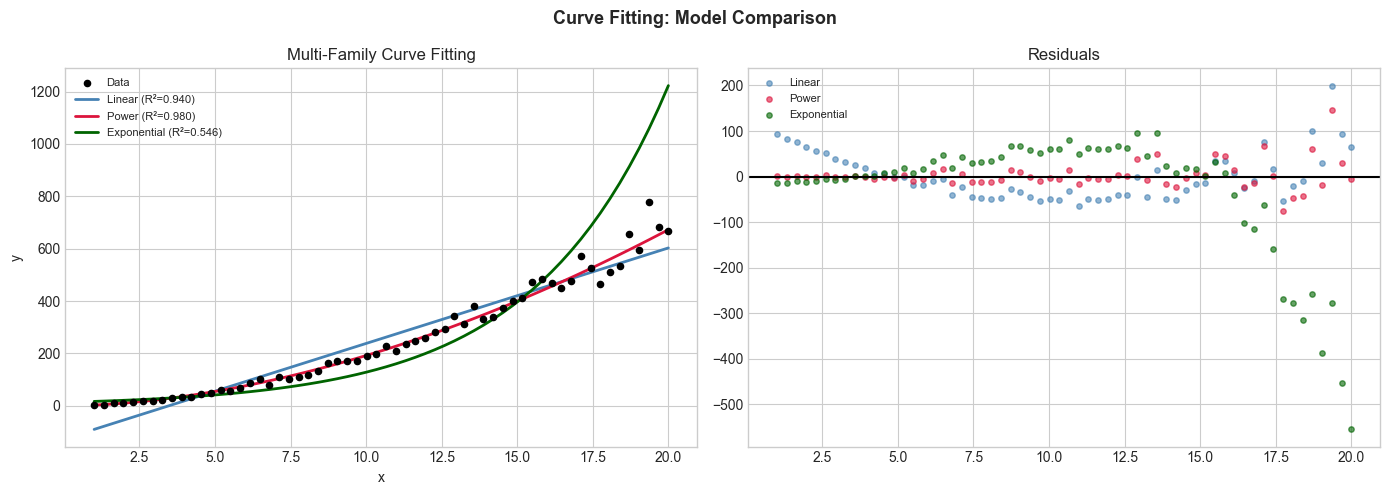

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(5)
x = np.linspace(1, 20, 60)

# True model: power law y = 3*x^1.8
y_true = 3 * x**1.8
y_obs = y_true * np.exp(np.random.normal(0, 0.1, 60))

def fit_linear(x, y):
    A = np.column_stack([x, np.ones(len(x))])
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return lambda x: m*x + b, m, b

def fit_power(x, y):
    lx, ly = np.log(x), np.log(y)
    A = np.column_stack([lx, np.ones(len(lx))])
    n, la = np.linalg.lstsq(A, ly, rcond=None)[0]
    return lambda x: np.exp(la)*x**n, np.exp(la), n

def fit_exp(x, y):
    ly = np.log(y)
    A = np.column_stack([x, np.ones(len(x))])
    b, la = np.linalg.lstsq(A, ly, rcond=None)[0]
    return lambda x: np.exp(la)*np.exp(b*x), np.exp(la), b

def r2(y, y_hat):
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x, y_obs, color='black', s=20, zorder=5, label='Data')

for name, fit_fn, color in [('Linear', fit_linear, 'steelblue'), ('Power', fit_power, 'crimson'), ('Exponential', fit_exp, 'darkgreen')]:
    f_fit, *params = fit_fn(x, y_obs)
    y_hat = f_fit(x)
    score = r2(y_obs, y_hat)
    axes[0].plot(x, y_hat, color=color, linewidth=2, label=f'{name} (R²={score:.3f})')
    residuals = y_obs - y_hat
    axes[1].scatter(x, residuals, color=color, s=15, alpha=0.6, label=f'{name}')

axes[0].set_title('Multi-Family Curve Fitting'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[1].axhline(0, color='black'); axes[1].set_title('Residuals'); axes[1].legend(fontsize=8)
plt.suptitle('Curve Fitting: Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Bootstrap Confidence Intervals

Power exponent: 1.8093 ± 0.0189
95% CI: [1.7732, 1.8489]
True value: 1.8


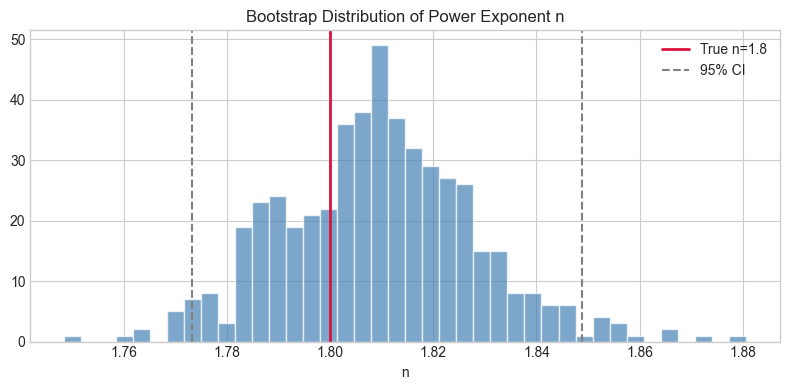

In [2]:
# Bootstrap to estimate uncertainty in fitted parameters
np.random.seed(0)
N_BOOT = 500
power_exponents = []

for _ in range(N_BOOT):
    idx = np.random.choice(len(x), len(x), replace=True)
    xb, yb = x[idx], y_obs[idx]
    lx, ly = np.log(xb), np.log(yb)
    A = np.column_stack([lx, np.ones(len(lx))])
    n_boot, _ = np.linalg.lstsq(A, ly, rcond=None)[0]
    power_exponents.append(n_boot)

power_exponents = np.array(power_exponents)
ci_lo, ci_hi = np.percentile(power_exponents, [2.5, 97.5])
print(f"Power exponent: {power_exponents.mean():.4f} ± {power_exponents.std():.4f}")
print(f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"True value: 1.8")

plt.figure(figsize=(8, 4))
plt.hist(power_exponents, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(1.8, color='crimson', linewidth=2, label='True n=1.8')
plt.axvline(ci_lo, color='gray', linestyle='--'); plt.axvline(ci_hi, color='gray', linestyle='--', label='95% CI')
plt.title('Bootstrap Distribution of Power Exponent n'); plt.xlabel('n'); plt.legend()
plt.tight_layout(); plt.show()

---

## Stage 3 — Polynomial Overfitting Demo

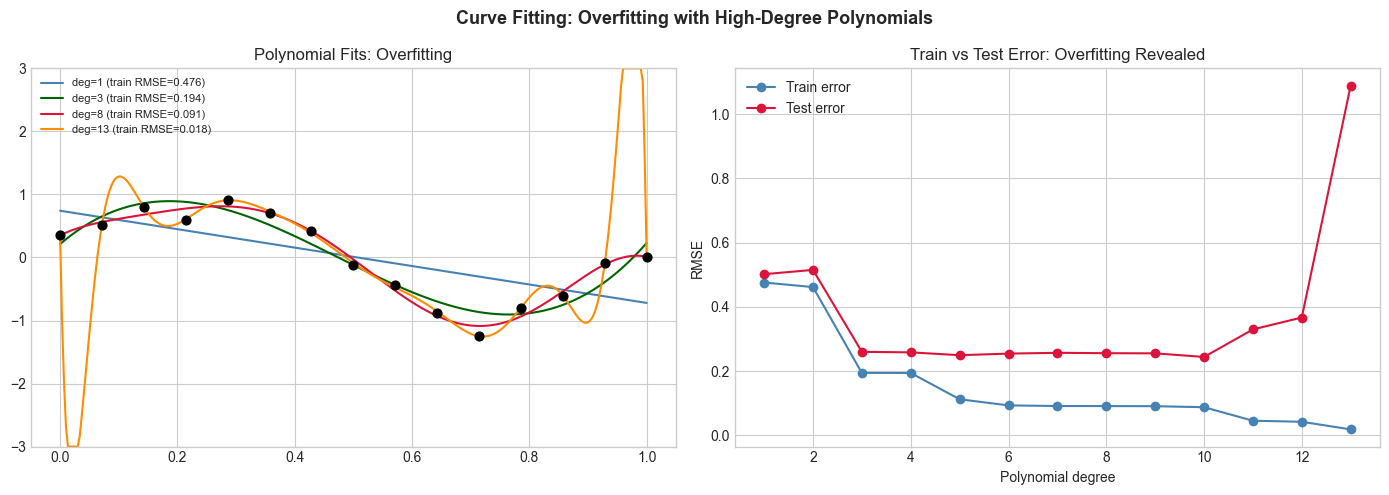

In [3]:
# Show overfitting with high-degree polynomials
np.random.seed(3)
x_small = np.linspace(0, 1, 15)
y_small = np.sin(2*np.pi*x_small) + np.random.normal(0, 0.2, 15)
x_fine = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for deg, color in [(1,'steelblue'),(3,'darkgreen'),(8,'crimson'),(13,'darkorange')]:
    coeffs = np.polyfit(x_small, y_small, deg)
    y_fit = np.polyval(coeffs, x_fine)
    y_train_hat = np.polyval(coeffs, x_small)
    train_rmse = np.sqrt(np.mean((y_small - y_train_hat)**2))
    axes[0].plot(x_fine, np.clip(y_fit, -3, 3), color=color, linewidth=1.5, label=f'deg={deg} (train RMSE={train_rmse:.3f})')

axes[0].scatter(x_small, y_small, color='black', s=40, zorder=5)
axes[0].set_ylim(-3, 3); axes[0].set_title('Polynomial Fits: Overfitting'); axes[0].legend(fontsize=8)

# Test error
x_test = np.linspace(0, 1, 100)
y_test = np.sin(2*np.pi*x_test) + np.random.normal(0, 0.2, 100)
degs = range(1, 14)
test_errors = [np.sqrt(np.mean((y_test - np.polyval(np.polyfit(x_small, y_small, d), x_test))**2)) for d in degs]
train_errors = [np.sqrt(np.mean((y_small - np.polyval(np.polyfit(x_small, y_small, d), x_small))**2)) for d in degs]

axes[1].plot(list(degs), train_errors, 'o-', color='steelblue', label='Train error')
axes[1].plot(list(degs), test_errors, 'o-', color='crimson', label='Test error')
axes[1].set_title('Train vs Test Error: Overfitting Revealed')
axes[1].set_xlabel('Polynomial degree'); axes[1].set_ylabel('RMSE'); axes[1].legend()
plt.suptitle('Curve Fitting: Overfitting with High-Degree Polynomials', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Multi-family curve fitting (linear/power/exponential), bootstrap uncertainty quantification, and polynomial overfitting demonstration.

**Extensions:** 1) Add regularized polynomial fitting (ridge regression). 2) Implement AIC/BIC model selection. 3) Apply to real dataset (e.g., kepler planet orbital data).